In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

from scipy.stats import hypergeom, fisher_exact

# GO enrichment
import gseapy as gp

Functions:

In [2]:
## Differential expression
def significant_DE(de_df, biotype_map, noise_prefixes, lfc_thresh=1.5, padj_thresh=0.01):
    """
    Filter DE result DataFrame into upregulated and downregulated gene lists.
    Args:
        de_df: raw output from sc.get.rank_genes_groups_df
        biotype_map: Series mapping gene names to is_protein_coding boolean
        noise_prefixes: tuple of gene prefixes to exclude from analysis (mitochondrial, ribosomal, etc.)
        lfc_thresh: absolute logFC threshold (applied symmetrically)
        padj_thresh: adjusted p-value threshold
    Returns:
        (genes_up, genes_down): two lists of gene names
    """
    df = de_df.copy()
    df['is_protein_coding'] = df['names'].map(biotype_map).fillna(False)

    # Base quality filters
    mask_base = (
        (df['is_protein_coding'] == True) &
        (df['pvals_adj'] < padj_thresh) &
        (~df['names'].str.startswith(noise_prefixes))
    )

    genes_up = (
        df[mask_base & (df['logfoldchanges'] > lfc_thresh)]
        .sort_values('logfoldchanges', ascending=False)
        ['names'].tolist()
    )
    genes_down = (
        df[mask_base & (df['logfoldchanges'] < -lfc_thresh)]
        .sort_values('logfoldchanges', ascending=True)  # most negative first
        ['names'].tolist()
    )

    return genes_up, genes_down

# =========================================================

## GO enrichment
def run_go_enrichment(gene_list: list, label: str, min_genes: int = 5) -> pd.DataFrame | None:
    """
    Runs gseapy Enrichr on a gene list and prints significant GO terms.
    Returns the full results DataFrame, or None if not enough genes.

    Args:
        gene_list: list of gene symbols
        label: descriptive label for print output
        min_genes: minimum number of genes required to run enrichment
    """
    print(f"\n{'='*55}")
    print(f" GO: {label}  ({len(gene_list)} genes)")
    print(f"{'='*55}")

    if len(gene_list) < min_genes:
        print(f"  Not enough genes (min={min_genes}). Skipping.")
        return None

    enrichment = gp.enrichr(
        gene_list=gene_list,
        gene_sets='GO_Biological_Process_2021',
        organism='mouse',
        outdir=None,
        no_plot=True
    )

    results = enrichment.results.sort_values('Adjusted P-value')
    sig_terms = results[results['Adjusted P-value'] < 0.05]

    if len(sig_terms) == 0:
        print("  No significant terms found (padj < 0.05).")
    else:
        for _, row in sig_terms.iterrows():
            clean_term = row['Term'].split(' (GO:')[0]
            print(f"  * {clean_term}  (padj={row['Adjusted P-value']:.1e})")

    return results

# =========================================================

# Cooperative TF analysis
def find_cooperative_tfs(de_genes: list, base_GRN: pd.DataFrame,
                         pval_thresh: float = 0.01) -> pd.DataFrame:
    """
    For each TF in the base GRN, tests whether its targets are significantly
    enriched in the DE gene list via hypergeometric test.
    Useful for identifying master regulators cooperating with a lncRNA.

    Returns a DataFrame ranked by overlap foldchange from expected, filtered by p-value.

    Note that both overlap fraction and fold enrichment are reported, as they can differ in cases of small target sets.
    """
    universe_genes = set(base_GRN['target'].unique())
    M = len(universe_genes)

    # DE genes restricted to the GRN universe
    de_in_universe = set(de_genes).intersection(universe_genes)
    N = len(de_in_universe)

    results = []
    for tf, group in base_GRN.groupby('source'):
        tf_targets = set(group['target'].unique())
        n = len(tf_targets)
        x = len(tf_targets.intersection(de_in_universe))

        if x == 0:      # no overlap, skip to save time (pval will be 1)
            continue

        expected = n * N / M    # hypergeometric mean
        fold_enrichment = x / expected if expected > 0 else float('inf')
        pval = hypergeom.sf(x - 1, M, n, N)
        results.append({
            'TF':      tf,
            'n_tf_targets':  n,
            'n_de_genes':    N,
            'overlap': x,
            'overlap_fraction': x / n,                      # -> what fraction of target are in DE list?
            'expected':         round(expected, 2),         # -> what overlap is expected by chance?
            'fold_enrichment':  round(fold_enrichment, 2),  # -> what fold enrichment from expected?
            'pval':    pval
        })

    df = pd.DataFrame(results)
    df = df[df['pval'] < pval_thresh]
    df = df.sort_values('fold_enrichment', ascending=False).reset_index(drop=True)

    # BH correction on the surviving hits
    from statsmodels.stats.multitest import multipletests
    if len(df) > 0:
        _, pvals_adj, _, _ = multipletests(df['pval'], method='fdr_bh')
        df['pval_adj'] = pvals_adj

    return df

# =========================================================

# Volcano and histogram plot of the overlap fold enrichment
def plot_tf_enrichment_landscape(coop_df, highlight_tfs, title):
    """
    Volcano-style plot: fold enrichment vs significance.
    Highlights specific TFs of interest.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Volcano (fold enrichment vs significance) ---
    ax = axes[0]
    ax.scatter(
        coop_df['fold_enrichment'],
        -np.log10(coop_df['pval_adj']),
        s=10, alpha=0.4, color='grey'
    )
    for tf in highlight_tfs:
        row = coop_df[coop_df['TF'] == tf]
        if not row.empty:
            ax.scatter(
                row['fold_enrichment'],
                -np.log10(row['pval_adj']),
                s=80, zorder=5, label=tf
            )
            ax.annotate(
                tf,
                xy=(row['fold_enrichment'].values[0], -np.log10(row['pval_adj'].values[0])),
                xytext=(5, 3), textcoords='offset points', fontsize=8
            )
    ax.axhline(-np.log10(0.05), linestyle='--', color='red', linewidth=0.8)
    ax.set_xlabel('Fold enrichment (observed / expected)')
    ax.set_ylabel('-log10(pval_adj)')
    ax.set_title(f'{title}\nVolcano: all TFs')
    ax.legend()

    # --- Plot 2: Distribution of fold enrichments with specific TF positions ---
    ax2 = axes[1]
    ax2.hist(coop_df['fold_enrichment'], bins=50, color='grey', alpha=0.6)
    colors = plt.cm.tab10(range(len(highlight_tfs)))  # o 'tab20', 'Set1', etc.

    for i, tf in enumerate(highlight_tfs):
        row = coop_df[coop_df['TF'] == tf]
        if not row.empty:
            ax2.axvline(
                row['fold_enrichment'].values[0],
                linestyle='--', linewidth=1.5, color=colors[i], label=tf
            )
    ax2.set_xlabel('Fold enrichment')
    ax2.set_ylabel('Number of TFs')
    ax2.set_title('Distribution of fold enrichments')
    ax2.legend()

    plt.tight_layout()

    base_name = "tf_enrichment_landscape"
    ext = ".png"
    i = 1
    filename = f"{base_name}{ext}"
    while os.path.exists(filename):
        filename = f"{base_name}_{i}{ext}"
        i += 1
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    print(f"Figure saved as: {filename}")    
    plt.show()

## Load data

-> processed with noisy clusters filtered

-> including base GRN

In [3]:
# --- LOAD AnnData ---
adata = sc.read_h5ad("../data/data_diff_express_lncRNA.h5ad")

## CellOracle base GRN for mouse 
#base_GRN_raw = pd.read_parquet("../data/celloracle_data/TFinfo_data/mm9_mouse_atac_atlas_data_TSS_and_cicero_0.9_accum_threshold_10.5_DF_peaks_by_TFs_v202204.parquet")

# Already in edge_list:
base_GRN = pd.read_parquet('../data/celloracle_data/base_GRN_edge_list.parquet')

NOTE: non-protein genes are not in adata since filtered. We see that apparently C13 is marked as protein coding!!

In [4]:
# Verify lncRNA presence in the dataset
print(f"'Rmst' in adata.var_names: {'Rmst' in adata.var_names}")
print(f"'Rmst' in adata.raw.var_names: {'Rmst' in adata.raw.var_names}")
print('    ')

print(f"'C13' in adata.var_names: {'C130026L21Rik' in adata.var_names}")
print(f"'C13' in adata.raw.var_names: {'C130026L21Rik' in adata.raw.var_names}")
print('    ')
print('    ')

print(f"Annotated gene biotype for Rmst: {adata.raw.var.loc['Rmst', 'gene_biotype']}") # we need to check in .raw
print('    ')

print(f"Annotated gene biotype for C13: {adata.raw.var.loc['C130026L21Rik', 'gene_biotype']}")

'Rmst' in adata.var_names: False
'Rmst' in adata.raw.var_names: True
    
'C13' in adata.var_names: False
'C13' in adata.raw.var_names: True
    
    
Annotated gene biotype for Rmst: lincRNA
    
Annotated gene biotype for C13: lincRNA


## Differential expression ASO perturbed cluster VS control

-> we need this information to establish the connections of RMST1 and C13 lncRNA in the base GRN in CellOracle

-> necessary to consider the differences between these two clusters to only get the causality of the ASO

-> we compared neg. control cells in ecto. clusters (1/3) VS ASO protocol cells per lncRNA in the perturbed cluster (5)

In [5]:
# Inicialize new .obs column for protocol + cluster information
adata.obs['phenotype_state'] = 'Other'

## Mask for neg. control cells in ecto. clusters
mask_ecto_control = (adata.obs['leiden_annotated'].isin(['Ectoderm_1', 'Ectoderm_2'])) & \
                       (adata.obs['diff_protocol'] == 'mES_ectodiff_asoNegControl')

## Mask for neg. control cells in ecto. clusters
mask_ecto_unperturbed = (adata.obs['leiden_annotated'].isin(['Ectoderm_1', 'Ectoderm_2'])) & \
                       (adata.obs['diff_protocol'] == 'mES_ectodiff')

## Mask for C13 in perturbed cluster
mask_c13_perturbed = (adata.obs['leiden_annotated'] == 'ASO_KO') & \
                    (adata.obs['diff_protocol'] == 'mES_ectodiff_asoC13')

## Mask for RMST1 in perturbed cluster
mask_rmst1_perturbed = (adata.obs['leiden_annotated'] == 'ASO_KO') & \
                      (adata.obs['diff_protocol'] == 'mES_ectodiff_asoRMST1')

# Save the metadata
adata.obs.loc[mask_ecto_control, 'phenotype_state'] = 'Control_Ecto'
adata.obs.loc[mask_ecto_unperturbed, 'phenotype_state'] = 'Unperturbed_Ecto'
adata.obs.loc[mask_c13_perturbed, 'phenotype_state'] = 'C13_perturbation'
adata.obs.loc[mask_rmst1_perturbed, 'phenotype_state'] = 'RMST1_perturbation'

## We work only with the defined phenotypes for the DE analysis
adata_pheno = adata[(adata.obs['phenotype_state'] != 'Other') & 
                     (adata.obs['phenotype_state'] != 'Unperturbed_Ecto')].copy()

print("Cells per phenotype:")
print(adata_pheno.obs['phenotype_state'].value_counts())

print("   ")
print("   ")

## DE analysis: each phenotype vs. ecto. control
sc.tl.rank_genes_groups(
    adata_pheno,
    groupby='phenotype_state',
    reference='Control_Ecto', 
    method='wilcoxon',      
    corr_method='benjamini-hochberg',
    use_raw=True, 
    key_added='DE_ASO_vs_Control'
)

## Extracting DE between control and each perturbation
de_c13 = sc.get.rank_genes_groups_df(adata_pheno, group='C13_perturbation', key='DE_ASO_vs_Control')
de_rmst1 = sc.get.rank_genes_groups_df(adata_pheno, group='RMST1_perturbation', key='DE_ASO_vs_Control')

# --- APPLY FILTERS ---
# 1. Protein coding only
# 2. Significant (p_adj < 0.01)
# 3. High Amplitude (LogFC > 1.5)
# 4. Remove Ribosomic/Mitochondrial genes

noise_prefixes = ('Rps', 'Rpl', 'mt-', 'MT-')
biotype_map = adata.raw.var['is_protein_coding'].fillna(False)

# de_c13 and de_rmst1 are the FULL unfiltered DE DataFrames from rank_genes_groups_df
c13_up, c13_down     = significant_DE(de_c13, biotype_map, noise_prefixes)
rmst1_up, rmst1_down = significant_DE(de_rmst1, biotype_map, noise_prefixes)

print(f"C13   — UP: {len(c13_up)}, DOWN: {len(c13_down)}")
print(f"RMST1 — UP: {len(rmst1_up)}, DOWN: {len(rmst1_down)}")

## For later use: both up and down DE genes as candidates for the lncRNA targets:
sig_c13 = c13_up + c13_down
sig_rmst1 = rmst1_up + rmst1_down

os.makedirs("../data/ASO_vs_Control_DE", exist_ok=True)
pd.Series(sig_c13).to_csv("../data/ASO_vs_Control_DE/DE_C13.csv", index=False, header=False)
pd.Series(sig_rmst1).to_csv('../data/ASO_vs_Control_DE/DE_RMST1.csv', index=False, header=False)


Cells per phenotype:
Control_Ecto          102
C13_perturbation       77
RMST1_perturbation     72
Name: phenotype_state, dtype: int64
   
   
C13   — UP: 60, DOWN: 689
RMST1 — UP: 30, DOWN: 706


GO ontology of DE genes with control reference to check how the perturbation biologically affects the cell

In [7]:
# =============================================================
# GO ENRICHMENT PER PERTURBATION AND DIRECTION
# =============================================================

# Run GO for all four combinations
go_c13_up     = run_go_enrichment(c13_up,     "C13 UPREGULATED after KO")
go_c13_down   = run_go_enrichment(c13_down,   "C13 DOWNREGULATED after KO")
go_rmst1_up   = run_go_enrichment(rmst1_up,   "RMST1 UPREGULATED after KO")
go_rmst1_down = run_go_enrichment(rmst1_down, "RMST1 DOWNREGULATED after KO")


# =============================================================
# STORE RESULTS
# =============================================================

# Save GO results to parquet (one file per condition/direction)
os.makedirs("../data/ASO_vs_Control_GO", exist_ok=True)

for label, df in [
    ("c13_up",     go_c13_up),
    ("c13_down",   go_c13_down),
    ("rmst1_up",   go_rmst1_up),
    ("rmst1_down", go_rmst1_down),
]:
    if df is not None:
        df.to_parquet(f"../data/ASO_vs_Control_GO/{label}.parquet", index=False)

# Store gene lists in adata.uns for portability
adata.uns['aso_de_genes'] = {
    'c13_up':     c13_up,
    'c13_down':   c13_down,
    'rmst1_up':   rmst1_up,
    'rmst1_down': rmst1_down,
}


 GO: C13 UPREGULATED after KO  (60 genes)
  * mitochondrial electron transport, cytochrome c to oxygen  (padj=6.4e-07)
  * aerobic electron transport chain  (padj=3.9e-04)
  * mitochondrial ATP synthesis coupled electron transport  (padj=3.9e-04)
  * cellular response to chemical stress  (padj=2.6e-02)
  * interleukin-12-mediated signaling pathway  (padj=2.6e-02)
  * removal of superoxide radicals  (padj=2.6e-02)
  * sequestering of actin monomers  (padj=2.6e-02)
  * cellular response to interleukin-12  (padj=2.6e-02)
  * cellular response to superoxide  (padj=2.7e-02)
  * cellular response to oxidative stress  (padj=2.8e-02)

 GO: C13 DOWNREGULATED after KO  (689 genes)
  * nervous system development  (padj=1.4e-05)
  * positive regulation of transcription, DNA-templated  (padj=3.9e-05)
  * positive regulation of cell projection organization  (padj=9.2e-05)
  * regulation of axonogenesis  (padj=9.2e-05)
  * protein phosphorylation  (padj=1.5e-04)
  * regulation of myeloid cell differ

## Differential expression ASO perturbed cluster VS ectoderm

-> we compared cells in ecto. clusters (1/3) VS ASO protocol cells per lncRNA in the perturbed cluster (5)

GO ontology:

## Check common DE genes between RMST1 and C13

In [9]:
# ============================================
# Overlapping significance
# ============================================

# Tus sets
set1 = set(sig_c13)
set2 = set(sig_rmst1)

overlap_genes = set1 & set2

len1 = len(set1)
len2 = len(set2)
len_overlap = len(set1 & set2)

total_genes = len(adata.raw.var_names)  # población total (ej: 20000)

# Calcular p-valor de enriquecimiento
pval = hypergeom.sf(len_overlap - 1, total_genes, len1, len2)

print(f"Set 1 (C13): {len1} genes")
print(f"Set 2 (RMST1): {len2} genes")
print("     ")
print(f"Overlapping: {len_overlap} genes")

if pval < 0.05:
    print(f"SIGNIFICATIVE OVERLAPPING: p-value: {pval:.8e}")
    print("     ")
    print("     ")
else:
    print(f"SIGNIFICATIVE OVERLAPPING: p-value: {pval:.8e}")
    print("     ")
    print("     ")


# ============================================
# Overlapping directions
# ============================================

up_overlap = list(set(c13_up) & set(rmst1_up))
down_overlap = list(set(c13_down) & set(rmst1_down))
opposite_direction = list((set(c13_up) & set(rmst1_down)) | (set(c13_down) & set(rmst1_up)))

print(f"Overlapping genes with same direction: {len(up_overlap) + len(down_overlap)}")
print(f"From which we have:")
print("     ")
print(f"Up/Up direction: {len(up_overlap)}")
print(f"Down/Down direction: {len(down_overlap)}")
print("     ")
print("     ")
print(f"Overlapping genes with opposite direction: {len(opposite_direction)}")

# Store gene lists in adata.uns for portability
adata.uns['coregulated_RMST1_C13_genes'] = {
    'overlap_up':     up_overlap,
    'overlap_down':   down_overlap,
}

# ============================================
# Genes not overlapping for each type
# ============================================

non_overlapping_rmst1 = set2 - set1
non_overlapping_c13 = set1 - set2

non_overlapping_up_rmst1 = list(set(rmst1_up) & non_overlapping_rmst1)
non_overlapping_down_rmst1 = list(set(rmst1_down) & non_overlapping_rmst1)
non_overlapping_up_c13 = list(set(c13_up) & non_overlapping_c13)
non_overlapping_down_c13 = list(set(c13_down) & non_overlapping_c13)

adata.uns['specific_RMST1_C13_regulations'] = {
    'RMST1_specific_up':     non_overlapping_up_rmst1,
    'RMST1_specific_down':     non_overlapping_down_rmst1,
    'C13_specific_up':     non_overlapping_up_c13,
    'C13_specific_down':     non_overlapping_down_c13
}

Set 1 (C13): 749 genes
Set 2 (RMST1): 736 genes
     
Overlapping: 454 genes
SIGNIFICATIVE OVERLAPPING: p-value: 0.00000000e+00
     
     
Overlapping genes with same direction: 454
From which we have:
     
Up/Up direction: 26
Down/Down direction: 428
     
     
Overlapping genes with opposite direction: 0


GO terms of common genes:

In [10]:
# Run GO
go_overlap_up     = run_go_enrichment(up_overlap,     "COREGULATED UP GENES OF RMST1 AND C13")
go_overlap_down   = run_go_enrichment(down_overlap,   "COREGULATED DOWN GENES OF RMST1 AND C13")

# =============================================================
# STORE RESULTS
# =============================================================

# Save GO results to parquet (one file per condition/direction)
os.makedirs("../data/Coregulation_RMST1_C13_GO", exist_ok=True)

for label, df in [
    ("overlap_up_go",     go_overlap_up),
    ("overlap_down_go",   go_overlap_down),
]:
    if df is not None:
        df.to_parquet(f"../data/Coregulation_RMST1_C13_GO/{label}.parquet", index=False)


 GO: COREGULATED UP GENES OF RMST1 AND C13  (26 genes)
  No significant terms found (padj < 0.05).

 GO: COREGULATED DOWN GENES OF RMST1 AND C13  (428 genes)
  * regulation of axonogenesis  (padj=2.0e-05)
  * positive regulation of axonogenesis  (padj=2.2e-05)
  * positive regulation of cell projection organization  (padj=2.5e-05)
  * nervous system development  (padj=8.0e-05)
  * axonogenesis  (padj=1.2e-04)
  * protein phosphorylation  (padj=4.6e-04)
  * axon guidance  (padj=2.8e-03)
  * enzyme linked receptor protein signaling pathway  (padj=3.0e-03)
  * retrograde axonal transport  (padj=3.8e-03)
  * activation of GTPase activity  (padj=3.8e-03)
  * phosphorylation  (padj=3.9e-03)
  * neuron projection development  (padj=3.9e-03)
  * peptidyl-threonine phosphorylation  (padj=7.4e-03)
  * axon development  (padj=8.2e-03)
  * negative regulation of microtubule polymerization or depolymerization  (padj=8.4e-03)
  * nucleus localization  (padj=9.1e-03)
  * regulation of cell migration

## Specificity of the lncRNA functions

=> GO terms of non-overlapping terms

In [11]:
# Run GO 
go_C13_specific_up     = run_go_enrichment(non_overlapping_up_c13,     "SPECIFICALLY C13 UPREGULATED GENES (NOT IN RMST1)")
go_C13_specific_down   = run_go_enrichment(non_overlapping_down_c13,   "SPECIFICALLY C13 DOWNREGULATED GENES (NOT IN RMST1)")
go_RMST1_specific_up   = run_go_enrichment(non_overlapping_up_rmst1,   "SPECIFICALLY RMST1 UPREGULATED GENES (NOT IN C13)")
go_RMST1_specific_down = run_go_enrichment(non_overlapping_down_rmst1, "SPECIFICALLY RMST1 DOWNREGULATED GENES (NOT IN C13)")

# =============================================================
# STORE RESULTS
# =============================================================

# Save GO results to parquet (one file per condition/direction)
import os
os.makedirs("../data/Specificity_RMST1_C13_GO", exist_ok=True)

for label, df in [
    ("C13_specific_up_go",     go_C13_specific_up),
    ("C13_specific_down_go",   go_C13_specific_down),
    ("RMST1_specific_up_go",   go_RMST1_specific_up),
    ("RMST1_specific_down_go", go_RMST1_specific_down),
]:
    if df is not None:
        df.to_parquet(f"../data/Specificity_RMST1_C13_GO/{label}.parquet", index=False)


 GO: SPECIFICALLY C13 UPREGULATED GENES (NOT IN RMST1)  (34 genes)
  * mitochondrial electron transport, cytochrome c to oxygen  (padj=1.1e-03)
  * removal of superoxide radicals  (padj=1.7e-02)
  * cellular response to superoxide  (padj=1.7e-02)
  * aerobic electron transport chain  (padj=1.7e-02)
  * mitochondrial ATP synthesis coupled electron transport  (padj=1.7e-02)
  * regulation of cholesterol biosynthetic process  (padj=2.2e-02)
  * regulation of oxidative stress-induced intrinsic apoptotic signaling pathway  (padj=2.2e-02)
  * cellular response to chemical stress  (padj=3.0e-02)
  * superoxide metabolic process  (padj=4.4e-02)
  * cellular response to oxidative stress  (padj=4.4e-02)
  * hydrogen peroxide metabolic process  (padj=4.4e-02)
  * protein insertion into membrane  (padj=4.5e-02)
  * retina homeostasis  (padj=4.6e-02)
  * protein insertion into ER membrane  (padj=4.6e-02)

 GO: SPECIFICALLY C13 DOWNREGULATED GENES (NOT IN RMST1)  (261 genes)
  * brain development  

## Inspecting the lncRNAs in the dataset

=> VASAseq is not able to sequence this ncRNA in depth: zero inflation phenomena.

In [12]:
genes = adata.raw.var_names.tolist()
genes = pd.Series(genes)

First we try to identify the C13 lncRNA, but a lot of lncRNA with prefix "C13"

In [13]:
# DEGs from ASO C13 protocol in 'de_c13'
lista_c13 = genes[genes.str.startswith("C13")].tolist()

# ASO perturbation data
target_candidates = de_c13[de_c13['names'].isin(lista_c13)]

# Sorted by logfoldchanges
print(target_candidates[['names', 'logfoldchanges', 'pvals_adj']].sort_values('logfoldchanges'))

                names  logfoldchanges  pvals_adj
230365  C130026L21Rik      -23.765644     1.0000
222589  C130060C02Rik      -23.743095     1.0000
223413  C130083A15Rik      -23.083708     1.0000
223576  C130040N14Rik      -20.769705     1.0000
219363  C130046K22Rik      -19.759468     1.0000
237338  C130021I20Rik       -4.178175     1.0000
242351  C130089K02Rik       -1.050500     0.0394
234313  C130013H08Rik       -0.941537     1.0000
205676  C130073F10Rik       -0.748643     1.0000
233365  C130012C08Rik       -0.717015     1.0000
234761  C130075A20Rik       -0.504382     1.0000
231512  C130023A14Rik       -0.216107     1.0000
225336  C130073E24Rik       -0.112065     1.0000
73294   C130080G10Rik        0.000000     1.0000
70295   C130083M11Rik        0.000000     1.0000
225154  C130071C03Rik        0.040487     1.0000
205861  C130051F05Rik        0.741484     1.0000
227792  C130074G19Rik        1.752790     1.0000
10734   C130036L24Rik        1.917256     1.0000
9648    C130050O18Ri

We look at the specific C130026I21Rik lncRNA of study:

In [14]:
# DEGs from ASO C13 protocol in 'de_c13'
list_c13 = genes[genes.str.startswith("C130026L21Rik")].tolist()

# ASO perturbation data
target_candidates = de_c13[de_c13['names'].isin(list_c13)]

# Sorted by logfoldchanges
print(target_candidates[['names', 'logfoldchanges', 'pvals_adj']].sort_values('logfoldchanges'))

                names  logfoldchanges  pvals_adj
230365  C130026L21Rik      -23.765644        1.0


Same for Rmst lncRNA:

In [15]:
# DEGs from ASO C13 protocol in 'de_rmst1'
list_rmst1 = genes[genes.str.startswith("Rmst")].tolist()

# ASO perturbation data
target_candidates = de_rmst1[de_rmst1['names'].isin(list_rmst1)]

# Sorted by logfoldchanges
print(target_candidates[['names', 'logfoldchanges', 'pvals_adj']].sort_values('logfoldchanges'))

       names  logfoldchanges  pvals_adj
241027  Rmst       -1.378326   0.333647


Since pvalues are 1, no statistical significance => from zero inflation.

We will check the # of cells where the lncRNA was sequenced and perform a Fisher test to identify significance of different sequencing between protocols:

In [16]:
# ------------------------
# ----    RMST1      ----
# ------------------------

target_gene = 'Rmst'

# Extract cells from Control and ASO
cels_ctrl_rmst1 = adata[adata.obs['experiment'] == 'mES_ectodiff_asoNegControl'].copy()
cels_aso_rmst1 = adata[adata.obs['experiment'] == 'mES_ectodiff_asoRMST1'].copy()

# Count non-zero counts of this lncRNA in the raw data
exp_ctrl_rmst1 = (cels_ctrl_rmst1.raw[:, target_gene].X > 0).sum()
exp_aso_rmst1 = (cels_aso_rmst1.raw[:, target_gene].X > 0).sum()

print(f"--- Zero inflation check for {target_gene} ---")
print(f"Non-zero control cells: {exp_ctrl_rmst1} of {cels_ctrl_rmst1.n_obs} ({(exp_ctrl_rmst1/cels_ctrl_rmst1.n_obs)*100:.2f}%)")
print(f"Non-zero ASO cells: {exp_aso_rmst1} of {cels_aso_rmst1.n_obs} ({(exp_aso_rmst1/cels_aso_rmst1.n_obs)*100:.2f}%)")

print(f"    ")
print(f"    ")

# ------------------------
# ----      C13      ----
# ------------------------

target_gene = 'C130026L21Rik'

# Extract cells from Control and ASO
cels_ctrl_c13 = adata[adata.obs['experiment'] == 'mES_ectodiff_asoNegControl'].copy()
cels_aso_c13 = adata[adata.obs['experiment'] == 'mES_ectodiff_asoC13'].copy()

# Count non-zero counts of this lncRNA in the raw data
exp_ctrl_c13 = (cels_ctrl_c13.raw[:, target_gene].X > 0).sum()
exp_aso_c13 = (cels_aso_c13.raw[:, target_gene].X > 0).sum()

print(f"--- Zero inflation check for {target_gene} ---")
print(f"Control cells expressing {target_gene}: {exp_ctrl_c13} of {cels_ctrl_c13.n_obs} ({(exp_ctrl_c13/cels_ctrl_c13.n_obs)*100:.2f}%)")
print(f"ASO cells expressing {target_gene}: {exp_aso_c13} of {cels_aso_c13.n_obs} ({(exp_aso_c13/cels_aso_c13.n_obs)*100:.2f}%)")

--- Zero inflation check for Rmst ---
Non-zero control cells: 45 of 141 (31.91%)
Non-zero ASO cells: 60 of 270 (22.22%)
    
    
--- Zero inflation check for C130026L21Rik ---
Control cells expressing C130026L21Rik: 11 of 141 (7.80%)
ASO cells expressing C130026L21Rik: 6 of 335 (1.79%)


Fisher test:

In [17]:
# Data from non-zero counts.
#
# Control -> A1 non-zero / A2 zero (total 150)
# ASO     -> B1 non-zero / B2 zero (total 321)

# Contingency table:
#
#               Express lncRNA | No Expression
# -------------------------------------------
# Control      |     A1       |    A2
# ASO.         |     B1       |    B2


# ------------------------
# ----    RMST1      ----
# ------------------------

contingency_table = [[exp_ctrl_rmst1, cels_ctrl_rmst1.n_obs - exp_ctrl_rmst1],
 [exp_aso_rmst1, cels_aso_rmst1.n_obs - exp_aso_rmst1]]

# Fisher's Test:
odds_ratio, p_value = fisher_exact(contingency_table, alternative='two-sided')

print(f"--- Fisher test: RMST1 ---")
print(f"Probability of ASO effect being non-significant: {p_value:.4f}")
# i.e. p-value for significative ASO effect

if p_value < 0.05:
    print("Significant ASO effect: we should include RMST1 in the GRN")
else:
    print("No significance: we should not include RMST1 in the GRN")

print(f"    ")
print(f"    ")

# ------------------------
# ----      C13      ----
# ------------------------

contingency_table = [[exp_ctrl_c13, cels_ctrl_c13.n_obs - exp_ctrl_c13],
 [exp_aso_c13, cels_aso_c13.n_obs - exp_aso_c13]]

# Fisher's Test:
odds_ratio, p_value = fisher_exact(contingency_table, alternative='two-sided')

print(f"--- Fisher test: C13 ---")
print(f"Probability of ASO effect being non-significant: {p_value:.4f}")
# i.e. p-value for significative ASO effect

if p_value < 0.05:
    print("Significant ASO effect: we should include C13 in the GRN")
else:
    print("No significance: we should not include C13 in the GRN")


--- Fisher test: RMST1 ---
Probability of ASO effect being non-significant: 0.0425
Significant ASO effect: we should include RMST1 in the GRN
    
    
--- Fisher test: C13 ---
Probability of ASO effect being non-significant: 0.0024
Significant ASO effect: we should include C13 in the GRN


## Potential coregulators of the lncRNAs

=> We use RMST1 as a control: we expect SOX2 to appear by looking at high overlapping TFs in the base GRN

=> Infer possible C13 coregulators with this method

=== RMST1 cooperative TFs (for downregulated DE genes) ===
     
Significant overlap TFs: 980

Sox2 rank: 222 / 980
  TF  n_tf_targets  overlap  expected  fold_enrichment     pval_adj
Sox2          4661      200    129.75             1.54 2.299000e-11

Top 20:
        TF  n_tf_targets  overlap  overlap_fraction  expected  fold_enrichment     pval_adj
    Znf136           298       19          0.063758      8.30             2.29 8.105955e-04
   Nanogp1           524       33          0.062977     14.59             2.26 1.601843e-05
    Znf586           318       20          0.062893      8.85             2.26 7.087762e-04
     Sox13           474       29          0.061181     13.19             2.20 8.322659e-05
     Zfhx3          1608       88          0.054726     44.76             1.97 1.202800e-09
     Rhox8           636       34          0.053459     17.70             1.92 2.689087e-04
    Rhox11           636       34          0.053459     17.70             1.92 2.689087e-04
   

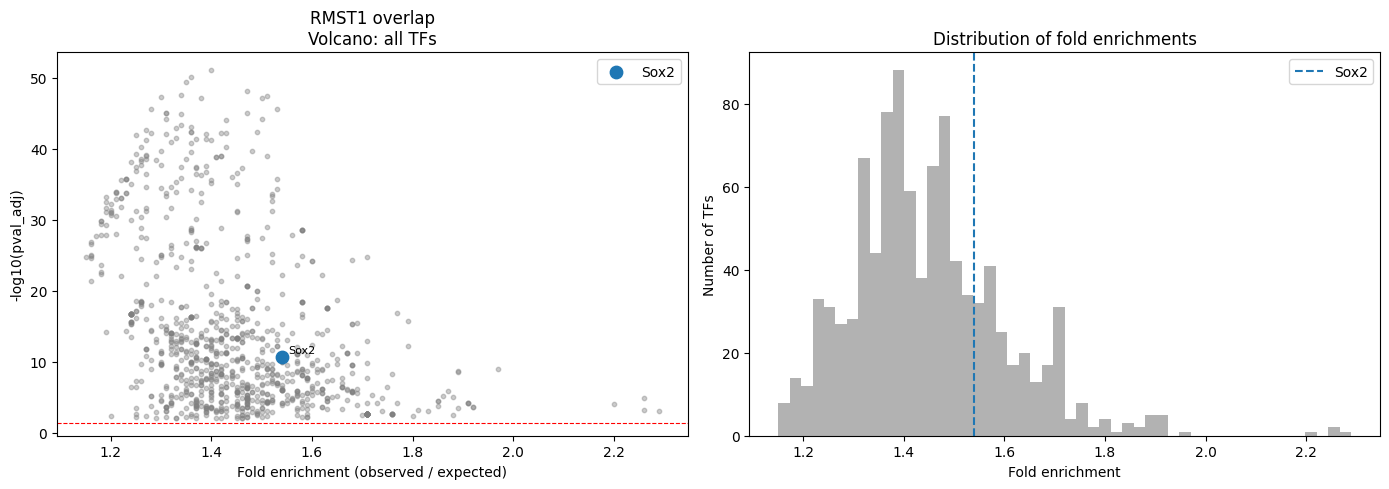

     
     
=== C13 cooperative TFs ===
     
Significant overlap TFs: 968
     
     TF  n_tf_targets  overlap  overlap_fraction  expected  fold_enrichment     pval_adj
    Ap3           237       18          0.075949      6.36             2.83 8.932472e-05
 Zfp187           299       20          0.066890      8.03             2.49 2.037988e-04
 Znf136           298       19          0.063758      8.00             2.38 5.187969e-04
 Tcfap4          1015       56          0.055172     27.25             2.06 4.007987e-07
Nanogp1           524       29          0.055344     14.07             2.06 2.340968e-04
   Gbx2          1058       58          0.054820     28.40             2.04 3.033377e-07
   Vax1           591       32          0.054146     15.87             2.02 1.685883e-04
   Dlx1           591       32          0.054146     15.87             2.02 1.685883e-04
    Bsx           591       32          0.054146     15.87             2.02 1.685883e-04
   Gsx2           591       3

In [18]:
# --- Run on rmst1_down ONLY (cooperative activation hypothesis) ---
print("=== RMST1 cooperative TFs (for downregulated DE genes) ===")
print("     ")

overlap_rmst1_down = find_cooperative_tfs(rmst1_down, base_GRN)

print(f"Significant overlap TFs: {len(overlap_rmst1_down)}")

sox2_row = overlap_rmst1_down[overlap_rmst1_down['TF'] == 'Sox2']
if not sox2_row.empty:
    rank = sox2_row.index[0] + 1
    print(f"\nSox2 rank: {rank} / {len(overlap_rmst1_down)}")
    print(sox2_row[['TF', 'n_tf_targets', 'overlap', 'expected',
                     'fold_enrichment', 'pval_adj']].to_string(index=False))

print("\nTop 20:")
print(overlap_rmst1_down[['TF', 'n_tf_targets', 'overlap', 'overlap_fraction', 'expected',
                         'fold_enrichment', 'pval_adj']].head(20).to_string(index=False))

plot_tf_enrichment_landscape(
    overlap_rmst1_down,
    highlight_tfs=['Sox2'],
    title='RMST1 overlap'
)

# --- Run on sig_c13 for discovery ---
print("     ")
print("     ")
print("=== C13 cooperative TFs ===")
print("     ")

overlap_c13 = find_cooperative_tfs(c13_down, base_GRN)

print(f"Significant overlap TFs: {len(overlap_c13)}")
print("     ")
print(overlap_c13[['TF', 'n_tf_targets', 'overlap', 'overlap_fraction', 'expected',
                 'fold_enrichment', 'pval_adj']].head(20).to_string(index=False))

We see that nearly the total of TFs has an enrichment of edge overlapping:

In [20]:
print("Number of unique TFs in the base GRN:")
base_GRN['source'].nunique()

Number of unique TFs in the base GRN:


1093

=> we should check this overlapping after the CellOracle pruning since now the network is too dense.